# 2. Anatomía de una neurona artificial

**Pregunta guía:** ¿cómo transforma una neurona varias entradas en una salida?

![Esquema conceptual de una neurona artificial](imagenes/neurona_artificial.png)

Una neurona realiza dos operaciones: combina entradas mediante una **suma ponderada** y aplica una **función de activación**.

## Entradas, pesos y sesgo

Para $x=(x_1,\ldots,x_d)$:

$$z=w_1x_1+\cdots+w_dx_d+b=w^Tx+b.$$

- Las **entradas** $x_i$ son características.
- Los **pesos** $w_i$ determinan influencia y sentido.
- El **sesgo** $b$ desplaza el umbral.
- $z$ es la combinación previa a la activación.

Un peso positivo favorece la respuesta cuando crece su entrada; uno negativo la dificulta; uno nulo elimina su influencia.

In [1]:
import torch
import matplotlib.pyplot as plt
AMARILLO, NEGRO, BLANCO, GRIS = "#F9C80E", "#111111", "#FFFFFF", "#B7B7B7"
torch.set_printoptions(precision=3, sci_mode=False)
print(f"PyTorch {torch.__version__}")

PyTorch 2.14.0


In [2]:
x = torch.tensor([0.8, 0.4, 0.2])
w = torch.tensor([1.5, -1.0, 0.5])
b = torch.tensor(-0.3)
contribuciones = x * w
z = contribuciones.sum() + b
print("Entradas:       ", x)
print("Pesos:          ", w)
print("Contribuciones: ", contribuciones)
print("Sesgo:          ", b.item())
print("Suma ponderada: ", z.item())

Entradas:        tensor([0.800, 0.400, 0.200])
Pesos:           tensor([ 1.500, -1.000,  0.500])
Contribuciones:  tensor([ 1.200, -0.400,  0.100])
Sesgo:           -0.30000001192092896
Suma ponderada:  0.6000000834465027


## Función umbral

El perceptrón clásico utiliza una activación escalón:

$$a(z)=\begin{cases}1,&z\geq0\\0,&z<0.\end{cases}$$

La salida es una decisión binaria: sí/no, activo/inactivo o clase 1/clase 0.

In [3]:
def escalon(z):
    return (z >= 0).to(torch.int)

salida = escalon(z)
print(f"z = {z.item():.3f} → salida = {salida.item()}")

z = 0.600 → salida = 1


## El sesgo mueve el umbral

Con una entrada y peso positivo, aumentar el sesgo facilita la activación; reducirlo exige una entrada mayor.

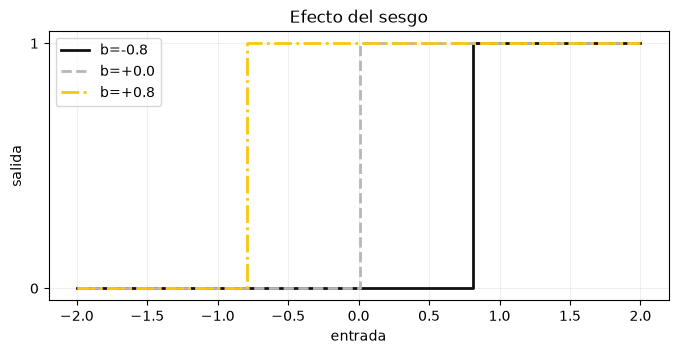

In [4]:
entradas = torch.linspace(-2, 2, 200)
fig, ax = plt.subplots(figsize=(8, 3.5))
for sesgo, color, estilo in [(-0.8, NEGRO, "-"), (0.0, GRIS, "--"), (0.8, AMARILLO, "-.")]:
    ax.step(entradas, escalon(entradas + sesgo), where="post",
            color=color, linestyle=estilo, linewidth=2, label=f"b={sesgo:+.1f}")
ax.set(xlabel="entrada", ylabel="salida", yticks=[0, 1], title="Efecto del sesgo")
ax.legend(); ax.grid(alpha=.2)
plt.savefig("imagenes/efecto_sesgo.png", dpi=160, bbox_inches="tight")
plt.show()

## Comprueba tu comprensión

1. Calcula la salida para $x=(1,0,1)$, $w=(2,-1,0.5)$ y $b=-2$.
2. ¿Qué sucede al multiplicar pesos y sesgo por 10?
3. Propón una característica que merezca un peso negativo.
4. Distingue la suma ponderada $z$ de la salida activada.

**Conclusión:** una neurona proyecta un vector y convierte el resultado en una decisión.